In [671]:
import pandas as pd
import numpy as np

In [672]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

In [673]:
df_test

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [674]:
df_train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# EDA

In [675]:
import matplotlib.pyplot as plt
import seaborn as sns

In [676]:
class EDA:
    def __init__(self, df_train, df_test):
        self.df_train = df_train
        self.df_test = df_test
    
    def describe(self):
        print("Train Data")
        print(self.df_train.describe())
    
        print("Test Data")
        print(self.df_test.describe())

    def histogram(self, column):
        plt.hist(self.df_train[column], bins=20, alpha=1, label='Train')
        plt.hist(self.df_test[column], bins=20, alpha=1, label='Test')
        plt.legend()
        plt.title(f'Histogram of {column}')
        plt.show()

    def distplot(self, column):
        sns.kdeplot(self.df_train[column], alpha=1, label='Train')
        sns.kdeplot(self.df_test[column], alpha=1, label='Test')
        plt.legend()
        plt.title(f'Distribution of {column}')
        plt.show()

    def countplot(self, column):
        sns.countplot(x=column, data=self.df_train, label='Train', alpha=1)
        sns.countplot(x=column, data=self.df_test, label='Test', alpha=1)
        plt.legend()
        plt.title(f'Countplot of {column}')
        plt.show()

    def piechart(self, column):
        plt.pie(self.df_train[column].value_counts(), autopct='%0.2f')
        plt.title(f'Piechart of Train {column}')
        plt.show()
        plt.pie(self.df_test[column].value_counts(), autopct='%0.2f')
        plt.title(f'Piechart of Test {column}')
        plt.show()

    def boxplot(self, column):
        sns.boxplot(x=column, data=self.df_train)
        plt.title(f'Boxplot of Train {column}')
        plt.show()
        sns.boxplot(x=column, data=self.df_test)
        plt.title(f'Boxplot of Test {column}')
        plt.show()
        
    def heatmap(self, columns):
        self.train_numeric_columns = self.df_train.select_dtypes(include=np.number).columns
        self.test_numeric_columns = self.df_test.select_dtypes(include=np.number).columns
        sns.heatmap(self.df_train[self.train_numeric_columns].corr(), annot=True)
        plt.title('Heatmap of Train Data')
        plt.show()
        sns.heatmap(self.df_test[self.test_numeric_columns].corr(), annot=True)
        plt.title('Heatmap of Test Data')
        plt.show()
              

eda = EDA(df_train, df_test)

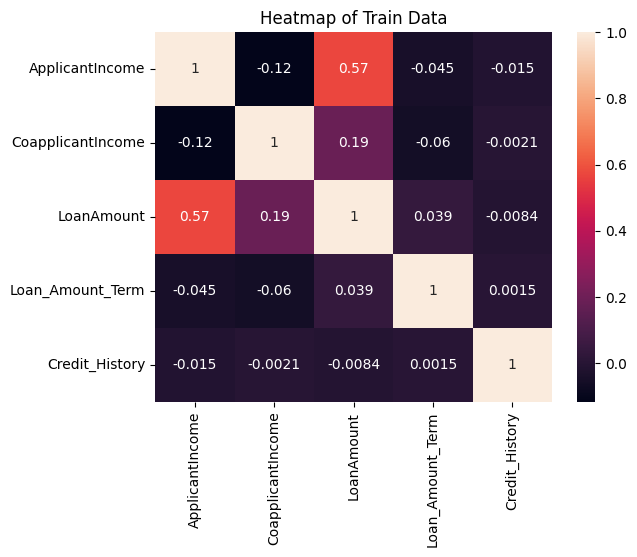

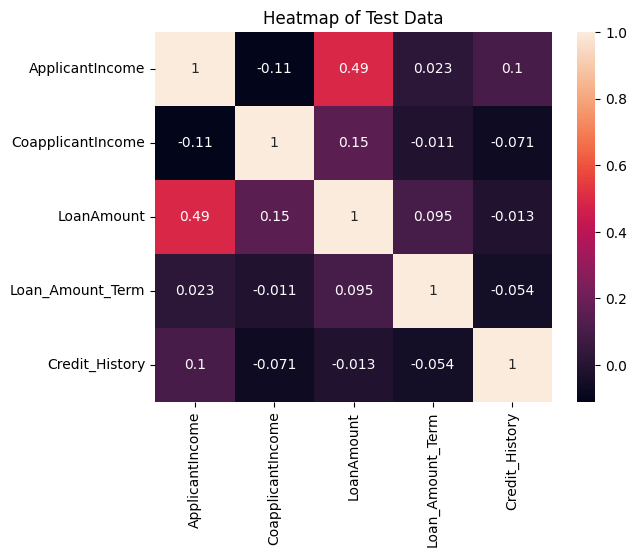

In [677]:
eda.heatmap(df_train.columns)

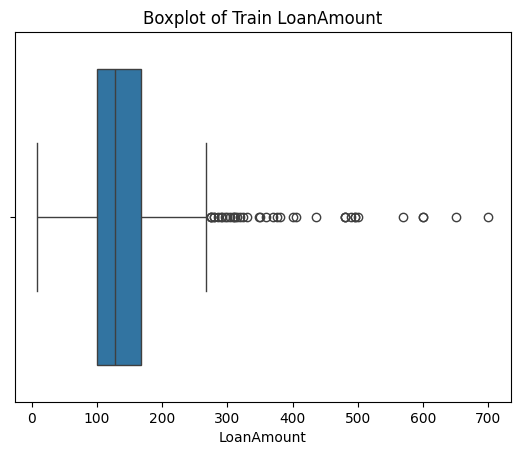

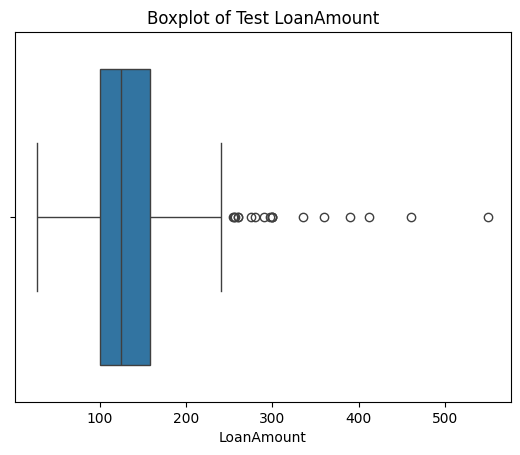

In [678]:
eda.boxplot('LoanAmount')

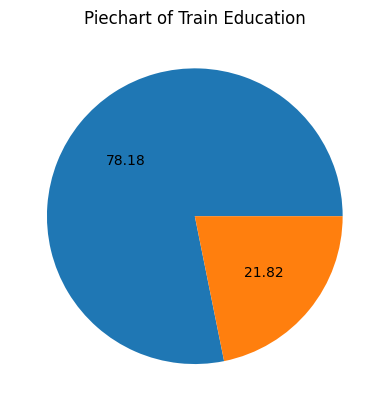

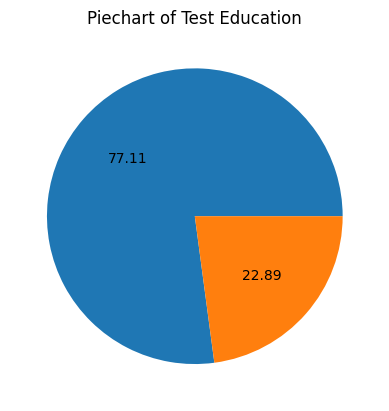

In [679]:
eda.piechart('Education')

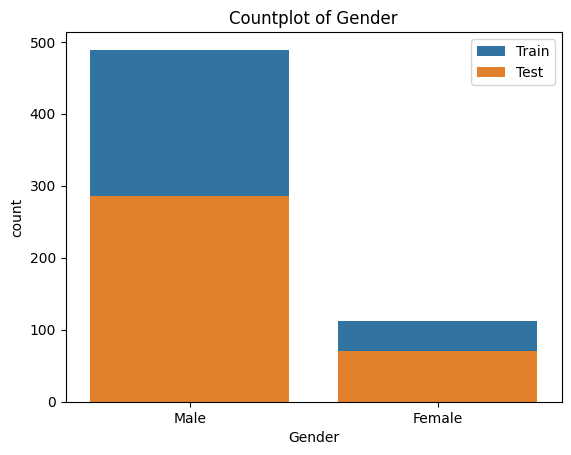

In [680]:
eda.countplot('Gender')

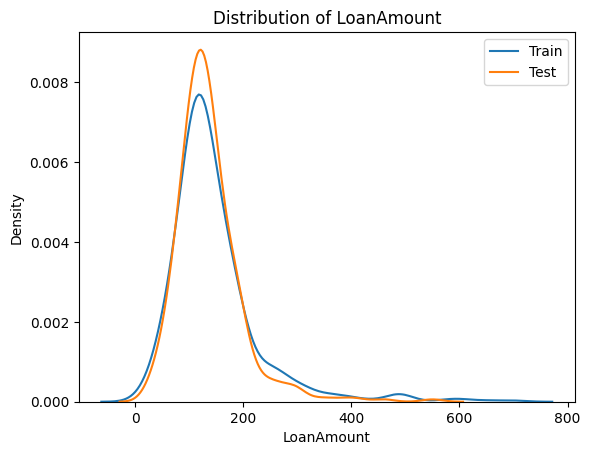

In [681]:
eda.distplot('LoanAmount')

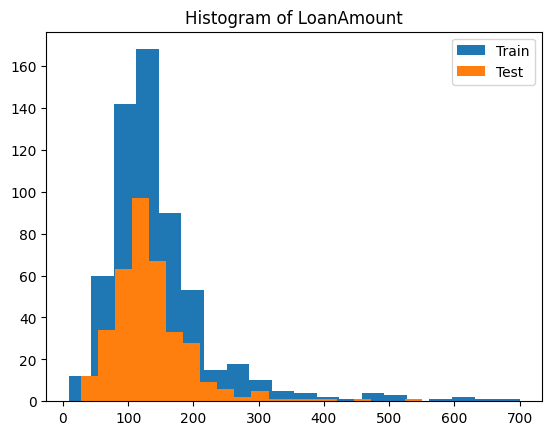

In [682]:
eda.histogram('LoanAmount')

In [683]:
eda.describe()

Train Data
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  
Test Data
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       

# Data preprocessing/Cleaning

In [ ]:
class Preprocessing:
    def __init__(self, df_train, df_test):
        self.df_train = df_train
        self.df_test = df_test
    
    def missing_values(self):
        print('Train Data')
        print(self.df_train.isnull().sum())
        print('Test Data')
        print(self.df_test.isnull().sum())

    def drop_columns(self, columns):
        self.df_train.drop(columns=['Loan_ID', 'Dependents', 'Self_Employed', 'Property_Area'], inplace=True, errors='ignore')
        self.df_test.drop(columns=['Loan_ID', 'Dependents', 'Self_Employed', 'Property_Area'], inplace=True, errors='ignore')

    def fill_missing_values(self):
        self.df_train['LoanAmount'].fillna(self.df_train['LoanAmount'].mean(), inplace=True)
        self.df_test['LoanAmount'].fillna(self.df_test['LoanAmount'].mean(), inplace=True)
        self.df_train['Loan_Amount_Term'].fillna(self.df_train['Loan_Amount_Term'].mean(), inplace=True)
        self.df_test['Loan_Amount_Term'].fillna(self.df_test['Loan_Amount_Term'].mean(), inplace=True)
        self.df_train['Credit_History'].fillna(self.df_train['Credit_History'].mode()[0], inplace=True)
        self.df_test['Credit_History'].fillna(self.df_test['Credit_History'].mode()[0], inplace=True)
        self.df_train['Gender'].fillna(self.df_train['Gender'].mode()[0], inplace=True)
        self.df_test['Gender'].fillna(self.df_test['Gender'].mode()[0], inplace=True)
        self.df_train['Married'].fillna(self.df_train['Married'].mode()[0], inplace=True)
        self.df_test['Married'].fillna(self.df_test['Married'].mode()[0], inplace=True)

prep = Preprocessing(df_train, df_test)

In [685]:
prep.drop_columns(['Loan_ID', 'Dependents', 'Self_Employed', 'Property_Area'])

In [686]:
df_train

,Gender,Married,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,Male,No,Graduate,5849,0.0,NaN,360.0,1.0,Y
1,Male,Yes,Graduate,4583,1508.0,128.0,360.0,1.0,N
2,Male,Yes,Graduate,3000,0.0,66.0,360.0,1.0,Y
3,Male,Yes,Not Graduate,2583,2358.0,120.0,360.0,1.0,Y
4,Male,No,Graduate,6000,0.0,141.0,360.0,1.0,Y
...,...,...,...,...,...,...,...,...,...
609,Female,No,Graduate,2900,0.0,71.0,360.0,1.0,Y
610,Male,Yes,Graduate,4106,0.0,40.0,180.0,1.0,Y
611,Male,Yes,Graduate,8072,240.0,253.0,360.0,1.0,Y
612,Male,Yes,Graduate,7583,0.0,187.0,360.0,1.0,Y


In [687]:
df_test

,Gender,Married,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,Male,Yes,Graduate,5720,0,110.0,360.0,1.0
1,Male,Yes,Graduate,3076,1500,126.0,360.0,1.0
2,Male,Yes,Graduate,5000,1800,208.0,360.0,1.0
3,Male,Yes,Graduate,2340,2546,100.0,360.0,NaN
4,Male,No,Not Graduate,3276,0,78.0,360.0,1.0
...,...,...,...,...,...,...,...,...
362,Male,Yes,Not Graduate,4009,1777,113.0,360.0,1.0
363,Male,Yes,Graduate,4158,709,115.0,360.0,1.0
364,Male,No,Graduate,3250,1993,126.0,360.0,NaN
365,Male,Yes,Graduate,5000,2393,158.0,360.0,1.0


In [688]:
prep.missing_values()

Train Data
Gender               13
Married               3
Education             0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Loan_Status           0
dtype: int64
Test Data
Gender               11
Married               0
Education             0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
dtype: int64


In [689]:
prep.fill_missing_values()

C:\Users\Pratik Shah\AppData\Local\Temp\ipykernel_4976\637263057.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df_train['LoanAmount'].fillna(self.df_train['LoanAmount'].mean(), inplace=True)
C:\Users\Pratik Shah\AppData\Local\Temp\ipykernel_4976\637263057.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are set

In [690]:
prep.missing_values()

Train Data
Gender               0
Married              0
Education            0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Loan_Status          0
dtype: int64
Test Data
Gender               0
Married              0
Education            0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64


# Feature Engineering

In [691]:
class Engineering:
    def __init__(self, df_train, df_test):
        self.df_train = df_train
        self.df_test = df_test
    
    def feature(self):
        self.df_train['TotalIncome'] = self.df_train['ApplicantIncome'] + self.df_train['CoapplicantIncome']
        self.df_test['TotalIncome'] = self.df_test['ApplicantIncome'] + self.df_test['CoapplicantIncome']

        self.df_train['Loan_Income_Ratio'] = self.df_train['LoanAmount'] / self.df_train['TotalIncome']
        self.df_test['Loan_Income_Ratio'] = self.df_test['LoanAmount'] / self.df_test['TotalIncome']

        self.df_train['EMI'] = self.df_train['LoanAmount'] / self.df_train['Loan_Amount_Term']
        self.df_test['EMI'] = self.df_test['LoanAmount'] / self.df_test['Loan_Amount_Term']

        
eng = Engineering(df_train, df_test)

In [692]:
eng.feature()

In [693]:
df_train

,Gender,Married,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Loan_Income_Ratio,EMI
0,Male,No,Graduate,5849,0.0,146.412162,360.0,1.0,Y,5849.0,0.025032,0.406700
1,Male,Yes,Graduate,4583,1508.0,128.000000,360.0,1.0,N,6091.0,0.021015,0.355556
2,Male,Yes,Graduate,3000,0.0,66.000000,360.0,1.0,Y,3000.0,0.022000,0.183333
3,Male,Yes,Not Graduate,2583,2358.0,120.000000,360.0,1.0,Y,4941.0,0.024287,0.333333
4,Male,No,Graduate,6000,0.0,141.000000,360.0,1.0,Y,6000.0,0.023500,0.391667
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,Graduate,2900,0.0,71.000000,360.0,1.0,Y,2900.0,0.024483,0.197222
610,Male,Yes,Graduate,4106,0.0,40.000000,180.0,1.0,Y,4106.0,0.009742,0.222222
611,Male,Yes,Graduate,8072,240.0,253.000000,360.0,1.0,Y,8312.0,0.030438,0.702778
612,Male,Yes,Graduate,7583,0.0,187.000000,360.0,1.0,Y,7583.0,0.024660,0.519444


In [694]:
df_test

,Gender,Married,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,Loan_Income_Ratio,EMI
0,Male,Yes,Graduate,5720,0,110.0,360.0,1.0,5720,0.019231,0.305556
1,Male,Yes,Graduate,3076,1500,126.0,360.0,1.0,4576,0.027535,0.350000
2,Male,Yes,Graduate,5000,1800,208.0,360.0,1.0,6800,0.030588,0.577778
3,Male,Yes,Graduate,2340,2546,100.0,360.0,1.0,4886,0.020467,0.277778
4,Male,No,Not Graduate,3276,0,78.0,360.0,1.0,3276,0.023810,0.216667
...,...,...,...,...,...,...,...,...,...,...,...
362,Male,Yes,Not Graduate,4009,1777,113.0,360.0,1.0,5786,0.019530,0.313889
363,Male,Yes,Graduate,4158,709,115.0,360.0,1.0,4867,0.023629,0.319444
364,Male,No,Graduate,3250,1993,126.0,360.0,1.0,5243,0.024032,0.350000
365,Male,Yes,Graduate,5000,2393,158.0,360.0,1.0,7393,0.021372,0.438889


# Remove column

In [695]:
df_train.drop(columns=['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term'], inplace=True, errors='ignore')
df_test.drop(columns=['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term'], inplace=True, errors='ignore')

In [696]:
df_train

,Gender,Married,Education,LoanAmount,Credit_History,Loan_Status,TotalIncome,Loan_Income_Ratio,EMI
0,Male,No,Graduate,146.412162,1.0,Y,5849.0,0.025032,0.406700
1,Male,Yes,Graduate,128.000000,1.0,N,6091.0,0.021015,0.355556
2,Male,Yes,Graduate,66.000000,1.0,Y,3000.0,0.022000,0.183333
3,Male,Yes,Not Graduate,120.000000,1.0,Y,4941.0,0.024287,0.333333
4,Male,No,Graduate,141.000000,1.0,Y,6000.0,0.023500,0.391667
...,...,...,...,...,...,...,...,...,...
609,Female,No,Graduate,71.000000,1.0,Y,2900.0,0.024483,0.197222
610,Male,Yes,Graduate,40.000000,1.0,Y,4106.0,0.009742,0.222222
611,Male,Yes,Graduate,253.000000,1.0,Y,8312.0,0.030438,0.702778
612,Male,Yes,Graduate,187.000000,1.0,Y,7583.0,0.024660,0.519444


In [697]:
df_test

,Gender,Married,Education,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio,EMI
0,Male,Yes,Graduate,110.0,1.0,5720,0.019231,0.305556
1,Male,Yes,Graduate,126.0,1.0,4576,0.027535,0.350000
2,Male,Yes,Graduate,208.0,1.0,6800,0.030588,0.577778
3,Male,Yes,Graduate,100.0,1.0,4886,0.020467,0.277778
4,Male,No,Not Graduate,78.0,1.0,3276,0.023810,0.216667
...,...,...,...,...,...,...,...,...
362,Male,Yes,Not Graduate,113.0,1.0,5786,0.019530,0.313889
363,Male,Yes,Graduate,115.0,1.0,4867,0.023629,0.319444
364,Male,No,Graduate,126.0,1.0,5243,0.024032,0.350000
365,Male,Yes,Graduate,158.0,1.0,7393,0.021372,0.438889


# split data


In [699]:
from sklearn.model_selection import train_test_split

x = df_train.drop(columns=['Loan_Status'])
y = df_train['Loan_Status']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [700]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 83 to 102
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             491 non-null    object 
 1   Married            491 non-null    object 
 2   Education          491 non-null    object 
 3   LoanAmount         491 non-null    float64
 4   Credit_History     491 non-null    float64
 5   TotalIncome        491 non-null    float64
 6   Loan_Income_Ratio  491 non-null    float64
 7   EMI                491 non-null    float64
dtypes: float64(5), object(3)
memory usage: 34.5+ KB


In [701]:
x_train

,Gender,Married,Education,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio,EMI
83,Male,Yes,Graduate,265.000000,1.0,8250.0,0.032121,0.736111
90,Male,Yes,Graduate,131.000000,1.0,5858.0,0.022363,0.363889
227,Male,Yes,Graduate,210.000000,1.0,7945.0,0.026432,0.583333
482,Male,Yes,Graduate,128.000000,1.0,5233.0,0.024460,0.355556
464,Male,No,Graduate,98.000000,0.0,4166.0,0.023524,0.272222
...,...,...,...,...,...,...,...,...
71,Male,Yes,Not Graduate,97.000000,1.0,3750.0,0.025867,0.269444
106,Male,Yes,Graduate,225.000000,1.0,12543.0,0.017938,0.625000
270,Female,No,Graduate,30.000000,1.0,3237.0,0.009268,0.083333
435,Female,Yes,Graduate,146.412162,1.0,10047.0,0.014573,0.610051


In [702]:
x_test

,Gender,Married,Education,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio,EMI
350,Male,Yes,Graduate,228.0,1.0,9083.0,0.025102,0.633333
377,Male,Yes,Graduate,130.0,1.0,4310.0,0.030162,0.361111
163,Male,Yes,Graduate,158.0,1.0,5614.0,0.028144,0.438889
609,Female,No,Graduate,71.0,1.0,2900.0,0.024483,0.197222
132,Male,No,Graduate,70.0,1.0,2718.0,0.025754,0.194444
...,...,...,...,...,...,...,...,...
231,Male,Yes,Graduate,42.0,1.0,3716.0,0.011302,0.233333
312,Female,No,Graduate,56.0,1.0,2507.0,0.022337,0.155556
248,Male,Yes,Graduate,123.0,1.0,4725.0,0.026032,0.256250
11,Male,Yes,Graduate,109.0,1.0,4340.0,0.025115,0.302778


# Feature Scaling and Encoding

In [703]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
class Transformer:
    def __init__(self, x_train):
        self.preprocessor = None
        self.cat_columns = x_train.select_dtypes(include='object').columns.tolist()
        self.num_columns = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
       
    def process(self):
        self.preprocessor = ColumnTransformer([
                    ('num', StandardScaler(), self.num_columns),
                    ('cat', OneHotEncoder(handle_unknown='ignore'), self.cat_columns)
         ])
        return self.preprocessor
    
    def fit_transform(self, x_train, x_test):
        self.process()
        x_train_processed = self.preprocessor.fit_transform(x_train)
        x_test_processed = self.preprocessor.transform(x_test)
        return x_train_processed, x_test_processed

trf = Transformer(x_train)

In [705]:
preprocessor = trf.process()

In [706]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [707]:
trf.fit_transform(x_train, x_test)


(array([[ 1.349992  ,  0.16730205,  0.93124476, ...,  1.        ,
          1.        ,  0.        ],
        [-0.20474803, -0.20640167, -0.16221162, ...,  1.        ,
          1.        ,  0.        ],
        [ 0.71185244,  0.1196517 ,  0.29373592, ...,  1.        ,
          1.        ,  0.        ],
        ...,
        [-1.37660433, -0.61588221, -1.62947967, ...,  0.        ,
          1.        ,  0.        ],
        [-0.02592784,  0.44804853, -1.03506648, ...,  1.        ,
          1.        ,  0.        ],
        [-0.02592784,  1.01094757, -1.46607408, ...,  1.        ,
          1.        ,  0.        ]], shape=(491, 10)),
 array([[ 0.92069811,  0.29744219,  0.14472268, ...,  1.        ,
          1.        ,  0.        ],
        [-0.21635057, -0.44824672,  0.71176096, ...,  1.        ,
          1.        ,  0.        ],
        [ 0.10852048, -0.24452195,  0.48558912, ...,  1.        ,
          1.        ,  0.        ],
        ...,
        [-0.29756833, -0.38341099,  0

# Model train

In [708]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [709]:
class Model:
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.base_models = {
            'Logistic Regression': LogisticRegression(),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
        }
        self.models = {}      #store trained models
        self.best_model = None     #best performing model store 

    def train(self, x_train, y_train):
        for name, model in self.base_models.items():
            print(f"Training {name}...")
            pipe = Pipeline([
                ('preprocessor', self.preprocessor),
                ('model', model)
            ])
            pipe.fit(x_train, y_train)
            self.models[name] = pipe 

    def evaluate(self, x_test, y_test):
        best_accuracy = 0
        for name, model in self.models.items():
            y_pred = model.predict(x_test)
            acc = accuracy_score(y_test, y_pred)
            print(f"{name} Accuracy: {acc}")
            if acc > best_accuracy:
                best_accuracy = acc
                self.best_model = model
        print(f"Best model: {self.best_model}")
        print("Best Model Evaluation:")
        y_pred = self.best_model.predict(x_test)
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    def probability(self, x_test):
        if self.best_model is not None:
            return self.best_model.predict_proba(x_test)[:, 1]
        else:
            raise Exception("No model trained yet!")

    def get_best_model(self):
        return self.best_model 
    
model = Model(preprocessor)

In [710]:
model.train(x_train, y_train)

Training Logistic Regression...
Training Random Forest...


In [711]:
model.evaluate(x_test, y_test)

Logistic Regression Accuracy: 0.6504065040650406
Random Forest Accuracy: 0.6341463414634146
Best model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['LoanAmount', 'TotalIncome',
                                                   'Loan_Income_Ratio',
                                                   'EMI']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Married', 'Education'], dtype='object'))])),
                ('model', LogisticRegression())])
Best Model Evaluation:
Accuracy: 0.6504065040650406
Classification Report:
               precision    recall  f1-score   support

           N       0.50      0.05      0.09        43
           Y       0.66      0.97      0.78        80

    accuracy              

In [712]:
model.probability(x_test)

array([0.73979142, 0.72445326, 0.73426559, 0.71016488, 0.65227038,
       0.74982094, 0.71044726, 0.78453324, 0.55204899, 0.74506429,
       0.81827084, 0.72709414, 0.6222013 , 0.6561507 , 0.81548491,
       0.80523868, 0.67014919, 0.67972083, 0.73497803, 0.81073804,
       0.61589212, 0.72926765, 0.70269771, 0.72397934, 0.76122422,
       0.66608357, 0.64623591, 0.54803981, 0.65459009, 0.84531905,
       0.8047282 , 0.83920154, 0.70057842, 0.69139678, 0.69669263,
       0.59381843, 0.73578686, 0.76981928, 0.76122256, 0.60346602,
       0.64139941, 0.66823842, 0.78431026, 0.770952  , 0.70206392,
       0.63244062, 0.73674431, 0.78707127, 0.74649023, 0.72793242,
       0.39323169, 0.694796  , 0.72207431, 0.59425717, 0.73673303,
       0.46810429, 0.65937734, 0.71023555, 0.71712176, 0.71015584,
       0.53173704, 0.76389772, 0.76778306, 0.75353531, 0.75824782,
       0.68486517, 0.72349364, 0.75822247, 0.79817489, 0.66549122,
       0.58343432, 0.80096626, 0.73729237, 0.74261034, 0.74638

In [713]:
best_model = model.get_best_model()

In [714]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [715]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
